In [37]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

## Load Dataset

In [38]:
data_root = "/kaggle/input/datasets/menahilahmad/smogdetection/SmogDetection-master"

clear_path = "/kaggle/input/datasets/ahmedislam0/fog-or-smog-detection-dataset/Clear"
smog_path = "/kaggle/input/datasets/ahmedislam0/fog-or-smog-detection-dataset/foggy"

In [39]:
clear_images = [os.path.join(clear_path, f) for f in os.listdir(clear_path) if f.endswith(('.JPG','.jpeg','.jpg','.png'))]
smog_images = [os.path.join(smog_path, f) for f in os.listdir(smog_path) if f.endswith(('.JPG','.jpeg','.jpg','.png'))]

print(f"Clear images: {len(clear_images)}")
print(f"Smog images: {len(smog_images)}")

Clear images: 1128
Smog images: 1207


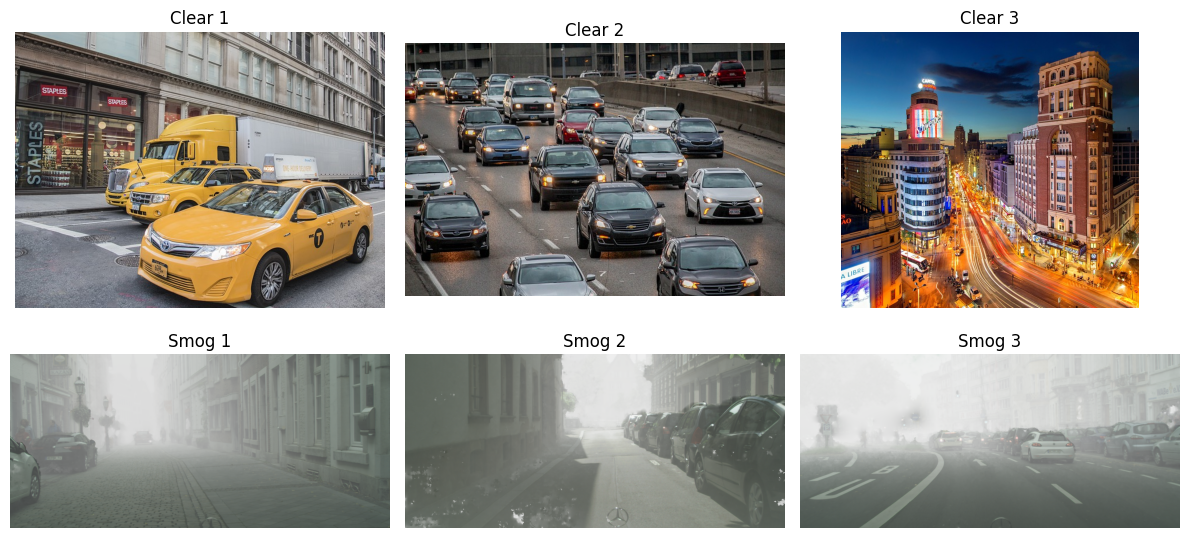

Total: 1128 clear, 1207 smoggy images


In [40]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

def visualize_samples(clear_images, smog_images, n=3):
    """
    Display n clear and n smoggy images side by side.
    """
    
    # Random sample
    random_clears = random.sample(clear_images, n)
    random_smogs = random.sample(smog_images, n)
    
    # Display
    fig, axes = plt.subplots(2, n, figsize=(4*n, 6))
    
    for i, img_path in enumerate(random_clears):
        img = Image.open(img_path)
        axes[0, i].imshow(img)
        axes[0, i].set_title(f"Clear {i+1}")
        axes[0, i].axis('off')
    
    for i, img_path in enumerate(random_smogs):
        img = Image.open(img_path)
        axes[1, i].imshow(img)
        axes[1, i].set_title(f"Smog {i+1}")
        axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Total: {len(clear_images)} clear, {len(smog_images)} smoggy images")

# Usage
visualize_samples(clear_images, smog_images, n=3)

In [41]:
import torch
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.datasets import ImageFolder

transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ADD THIS
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
])

# Reload dataset with augmentation
train_dataset = ImageFolder(root=data_root, transform=transform_train)
val_dataset = ImageFolder(root=data_root, transform=transform_val)

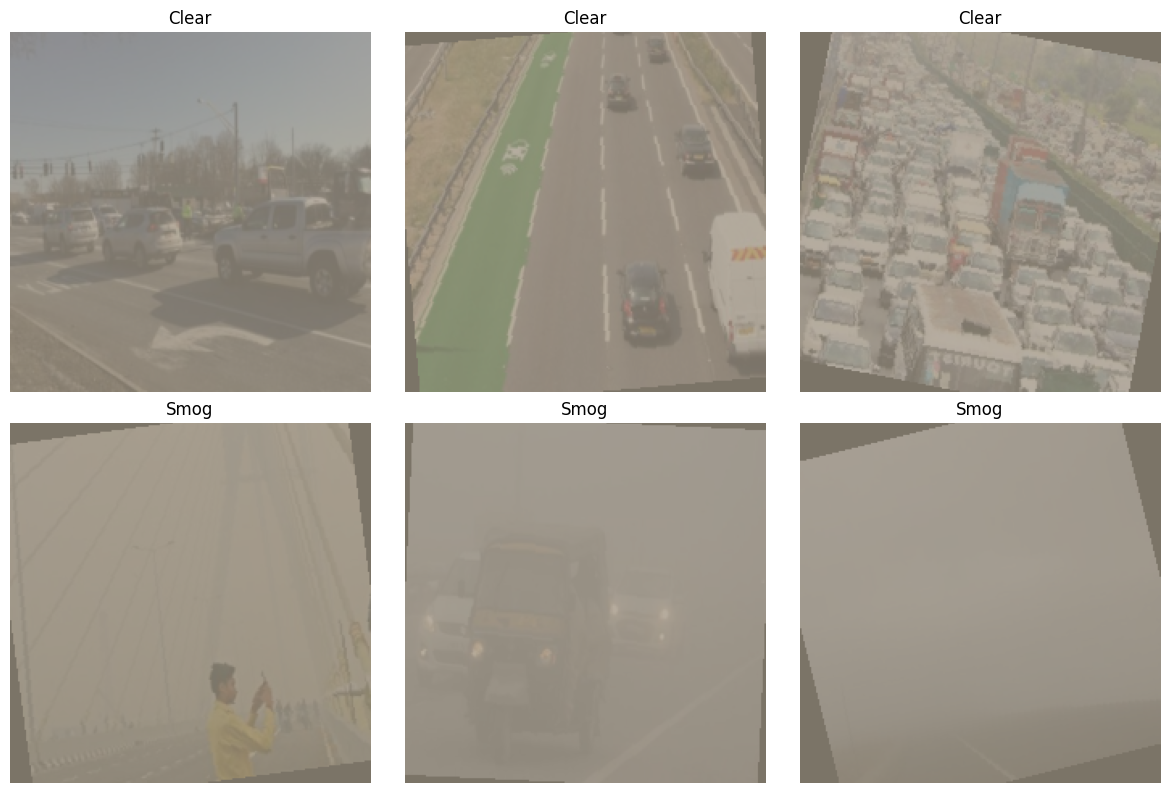

In [42]:
def visualize_transformed_dataset(dataset, num_clear=3, num_smog=3):
    """
    Visualize random clear and smog images after transforms.
    """
    
    # Get indices for each class
    clear_indices = [i for i, (_, label) in enumerate(dataset) if label == 0]
    smog_indices = [i for i, (_, label) in enumerate(dataset) if label == 1]
    
    # Random sample
    random_clear = random.sample(clear_indices, num_clear)
    random_smog = random.sample(smog_indices, num_smog)
    
    # Display
    fig, axes = plt.subplots(2, max(num_clear, num_smog), figsize=(4*max(num_clear, num_smog), 8))
    
    for i, idx in enumerate(random_clear):
        image, label = dataset[idx]
        
        # Denormalize
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        image = image * std + mean
        image = torch.clamp(image, 0, 1)
        
        image_np = image.numpy().transpose(1, 2, 0)
        axes[0, i].imshow(image_np)
        axes[0, i].set_title("Clear")
        axes[0, i].axis('off')
    
    for i, idx in enumerate(random_smog):
        image, label = dataset[idx]
        
        # Denormalize
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        image = image * std + mean
        image = torch.clamp(image, 0, 1)
        
        image_np = image.numpy().transpose(1, 2, 0)
        axes[1, i].imshow(image_np)
        axes[1, i].set_title("Smog")
        axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.show()


visualize_transformed_dataset(dataset, num_clear=3, num_smog=3)

In [43]:
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_dataset, _ = random_split(train_dataset, [train_size, val_size])
_, val_dataset = random_split(val_dataset, [train_size, val_size])

In [44]:
# dataloaders
batch_size = 32
train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True
)
val_loader = DataLoader(
    val_dataset, 
    batch_size=batch_size, 
    shuffle=False
)

In [45]:
images, labels = next(iter(train_loader))
print(f"Batch images shape: {images.shape}")
print(f"Batch labels: {labels}")

Batch images shape: torch.Size([32, 3, 224, 224])
Batch labels: tensor([0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
        0, 0, 1, 0, 0, 0, 1, 1])


In [46]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

Using device: cuda


In [47]:
import torch
import torch.nn as nn
from torchvision import models


# Create fresh model on CPU first
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 1)

model = model.to(device)

## Training

In [48]:
def train_step(model, dataloader, loss_fn, optimizer, device):
    model.train()
    train_loss, train_acc = 0, 0
    
    for X, y in dataloader:
        X, y = X.to(device), y.to(device)
        y = y.float().view(-1, 1)
        
        y_pred = model(X)  # Already has sigmoid
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Accuracy (no sigmoid needed)
        pred_class = (y_pred > 0.5).float()
        train_acc += (pred_class == y).sum().item() / len(y_pred)
    
    train_loss /= len(dataloader)
    train_acc /= len(dataloader)
    return train_loss, train_acc

def test_step(model, dataloader, loss_fn, device):
    model.eval()
    test_loss, test_acc = 0, 0
    
    with torch.inference_mode():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            y = y.float().view(-1, 1)
            
            y_pred = model(X)
            loss = loss_fn(y_pred, y)
            test_loss += loss.item()
            
            pred_class = (y_pred > 0.5).float()
            test_acc += (pred_class == y).sum().item() / len(y_pred)
    
    test_loss /= len(dataloader)
    test_acc /= len(dataloader)
    return test_loss, test_acc

In [49]:
from tqdm.auto import tqdm

def train(model, train_dataloader, test_dataloader, optimizer, loss_fn, device, epochs=10):
    results = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
    
    for epoch in range(epochs):
        train_loss, train_acc = train_step(model, train_dataloader, loss_fn, optimizer, device)
        test_loss, test_acc = test_step(model, test_dataloader, loss_fn, device)
        
        print(f"Epoch: {epoch+1} | train_loss: {train_loss:.4f} | train_acc: {train_acc:.4f} | test_loss: {test_loss:.4f} | test_acc: {test_acc:.4f}")
        
        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)
    
    return results

In [50]:
import torch.nn as nn
import torch.optim as optim

loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [51]:
# Run training
results = train(
    model=model,
    train_dataloader=train_loader,
    test_dataloader=val_loader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    device=device,
    epochs=10
)

Epoch: 1 | train_loss: 0.3770 | train_acc: 0.7875 | test_loss: 11.7023 | test_acc: 0.2656
Epoch: 2 | train_loss: 0.2879 | train_acc: 0.9375 | test_loss: 1.9337 | test_acc: 0.7188
Epoch: 3 | train_loss: 0.1744 | train_acc: 0.9313 | test_loss: 0.6522 | test_acc: 0.8594
Epoch: 4 | train_loss: 0.0880 | train_acc: 0.9625 | test_loss: 1.8520 | test_acc: 0.6875
Epoch: 5 | train_loss: 0.1053 | train_acc: 0.9625 | test_loss: 0.2064 | test_acc: 0.9375
Epoch: 6 | train_loss: 0.0820 | train_acc: 0.9625 | test_loss: 0.2139 | test_acc: 0.8438
Epoch: 7 | train_loss: 0.0917 | train_acc: 0.9500 | test_loss: 0.2605 | test_acc: 0.7500
Epoch: 8 | train_loss: 0.0938 | train_acc: 0.9688 | test_loss: 0.1219 | test_acc: 0.8906
Epoch: 9 | train_loss: 0.0925 | train_acc: 0.9625 | test_loss: 0.1305 | test_acc: 0.8750
Epoch: 10 | train_loss: 0.0849 | train_acc: 0.9375 | test_loss: 0.0363 | test_acc: 0.9844


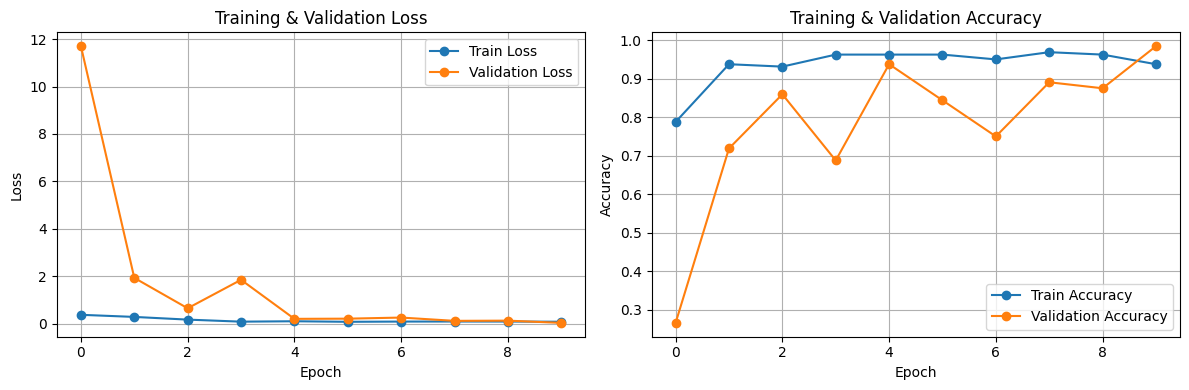

In [52]:
import matplotlib.pyplot as plt

def plot_results(results):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Plot losses
    ax1.plot(results["train_loss"], label="Train Loss", marker='o')
    ax1.plot(results["test_loss"], label="Validation Loss", marker='o')
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title("Training & Validation Loss")
    ax1.legend()
    ax1.grid(True)
    
    # Plot accuracies
    ax2.plot(results["train_acc"], label="Train Accuracy", marker='o')
    ax2.plot(results["test_acc"], label="Validation Accuracy", marker='o')
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.set_title("Training & Validation Accuracy")
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

# Call after training
plot_results(results)